# DepthBLIP-2 — Thực nghiệm trên B3DO & SUN3D

**Paper**: [DepthBLIP-2: Leveraging Language to Guide BLIP-2 in Understanding Depth Information (ACCV 2024)](https://openaccess.thecvf.com/content/ACCV2024/papers/Chen_DepthBLIP-2_Leveraging_Language_to_Guide_BLIP-2_in_Understanding_Depth_Information_ACCV_2024_paper.pdf)

## Mục tiêu
- Thực nghiệm DepthBLIP-2 trên **2 tập dữ liệu indoor** mới: **B3DO** và **SUN3D**
- So sánh **2 backbone**: BLIP-2 OPT-2.7B (`method=first`) và InstructBLIP Vicuna-7B (`method=second`)
- Đánh giá và so sánh với kết quả của tác giả trên tập NYU Depth V2

## Thông tin dataset & cấu hình

| Dataset | Loại   | H×W     | depth_scale | max_depth | Metric style |
|---------|--------|---------|-------------|-----------|-------------|
| B3DO    | Indoor | 480×640 | **10000** (0.1mm→m) | 10 m | NYU-style |
| SUN3D   | Indoor | 480×640 | **10000** (0.1mm→m) | 10 m | NYU-style |

## Kết quả tác giả (NYU Depth V2 — tham khảo indoor)

| Method | Fine-tune | Depth bin | abs_rel↓ | log10↓ | rmse↓ | a1↑ | a2↑ | a3↑ |
|--------|-----------|-----------|----------|--------|-------|-----|-----|-----|
| DepthBLIP-2 (Vicuna, **auto bins**) | MLP | auto | **0.363** | **0.153** | **1.132** | **0.401** | **0.707** | **0.898** |
| DepthBLIP-2 (Vicuna, prefix bins)   | MLP | prefix | 0.368 | 0.156 | 1.172 | 0.384 | 0.683 | 0.856 |
| DepthCLIP (baseline)                | 0-shot | prefix | 0.388 | 0.156 | 1.167 | 0.394 | 0.683 | 0.851 |

> **Ghi chú**: Tác giả chỉ báo cáo kết quả trên NYU. Kết quả B3DO/SUN3D là thực nghiệm mới của chúng ta.
> Training: 16 ảnh, 50 epochs, batch=16, lr=1e-3, AdamW (theo paper).

In [1]:
# ============================================================
# Cell 1: Import và thiết lập đường dẫn
# ============================================================
import os, sys, re, subprocess, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from pathlib import Path
from PIL import Image

warnings.filterwarnings("ignore")

ROOT   = Path("/media/ssd1tb/Long/depth-blip2")
PYTHON = "/home/hoangtv/anaconda3/envs/dat310/bin/python"
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# ── Cấu hình B3DO ────────────────────────────────────────────
B3DO_ROOT        = "./datasets/B3DO/"
B3DO_TRAIN_CSV   = "./datasets/B3DO/b3do_train.csv"
B3DO_VAL_CSV     = "./datasets/B3DO/b3do_val.csv"
B3DO_TEST_CSV    = "./datasets/B3DO/b3do_test.csv"
B3DO_DEPTH_SCALE = 10000.0   # 0.1mm → m
B3DO_HEIGHT      = 480
B3DO_WIDTH       = 640
B3DO_MAX_DEPTH   = 10.0

# ── Cấu hình SUN3D ───────────────────────────────────────────
SUN3D_ROOT        = "./datasets/SUN3D/"
SUN3D_TRAIN_CSV   = "./datasets/SUN3D/sun3d_train.csv"
SUN3D_VAL_CSV     = "./datasets/SUN3D/sun3d_val.csv"
SUN3D_TEST_CSV    = "./datasets/SUN3D/sun3d_test.csv"
SUN3D_DEPTH_SCALE = 10000.0   # 0.1mm → m
SUN3D_HEIGHT      = 480
SUN3D_WIDTH       = 640
SUN3D_MAX_DEPTH   = 10.0

# ── Kết quả tham khảo từ paper (NYU Depth V2) ───────────────
PAPER_VICUNA = dict(Label="Paper (Vicuna, auto_bins)",
                    Dataset="NYU",
                    abs_rel=0.363, log10=0.153, rmse=1.132,
                    a1=0.401, a2=0.707, a3=0.898)
PAPER_DEPTHCLIP = dict(Label="DepthCLIP (baseline)",
                        Dataset="NYU",
                        abs_rel=0.388, log10=0.156, rmse=1.167,
                        a1=0.394, a2=0.683, a3=0.851)

INDOOR_METRICS = ["abs_diff", "a1", "a2", "a3", "abs_rel", "log10", "rmse"]

print(f"ROOT   = {ROOT}")
print(f"PYTHON = {PYTHON}")
print(f"CUDA   = {torch.cuda.is_available()} (devices: {torch.cuda.device_count()})")

ROOT   = /media/ssd1tb/Long/depth-blip2
PYTHON = /home/hoangtv/anaconda3/envs/dat310/bin/python
CUDA   = True (devices: 2)


---
## 1. Kiểm tra dữ liệu

In [2]:
# ============================================================
# Cell 2: Kiểm tra trạng thái datasets
# ============================================================
def check_dataset(name, root, splits):
    """Kiểm tra dataset CSV và ảnh đầu tiên."""
    print(f"\n{'─'*50}")
    print(f"  Dataset: {name}")
    print(f"{'─'*50}")
    ok = True
    for split, path in splits:
        if not os.path.exists(path):
            print(f"  [MISS] {split:5s}: {path}")
            ok = False
            continue
        df = pd.read_csv(path, header=None, names=["rgb", "depth"])
        first_rgb = os.path.join(root, df.iloc[0]["rgb"])
        status = "✓" if os.path.isfile(first_rgb) else "✗ FILE NOT FOUND"
        print(f"  [{status}] {split:5s}: {len(df):3d} cặp — {path}")
        if not os.path.isfile(first_rgb):
            ok = False
    return ok

b3do_ok = check_dataset("B3DO", B3DO_ROOT, [
    ("train", B3DO_TRAIN_CSV),
    ("val",   B3DO_VAL_CSV),
    ("test",  B3DO_TEST_CSV),
])

sun3d_ok = check_dataset("SUN3D", SUN3D_ROOT, [
    ("train", SUN3D_TRAIN_CSV),
    ("val",   SUN3D_VAL_CSV),
    ("test",  SUN3D_TEST_CSV),
])

print(f"\n{'─'*50}")
print(f"  B3DO  : {'SẴN SÀNG' if b3do_ok else 'THIẾU DỮ LIỆU'}")
print(f"  SUN3D : {'SẴN SÀNG' if sun3d_ok else 'THIẾU DỮ LIỆU'}")


──────────────────────────────────────────────────
  Dataset: B3DO
──────────────────────────────────────────────────
  [✓] train:  42 cặp — ./datasets/B3DO/b3do_train.csv
  [✓] val  :   9 cặp — ./datasets/B3DO/b3do_val.csv
  [✓] test :   9 cặp — ./datasets/B3DO/b3do_test.csv

──────────────────────────────────────────────────
  Dataset: SUN3D
──────────────────────────────────────────────────
  [✓] train:  20 cặp — ./datasets/SUN3D/sun3d_train.csv
  [✓] val  :   4 cặp — ./datasets/SUN3D/sun3d_val.csv
  [✓] test :   4 cặp — ./datasets/SUN3D/sun3d_test.csv

──────────────────────────────────────────────────
  B3DO  : SẴN SÀNG
  SUN3D : SẴN SÀNG


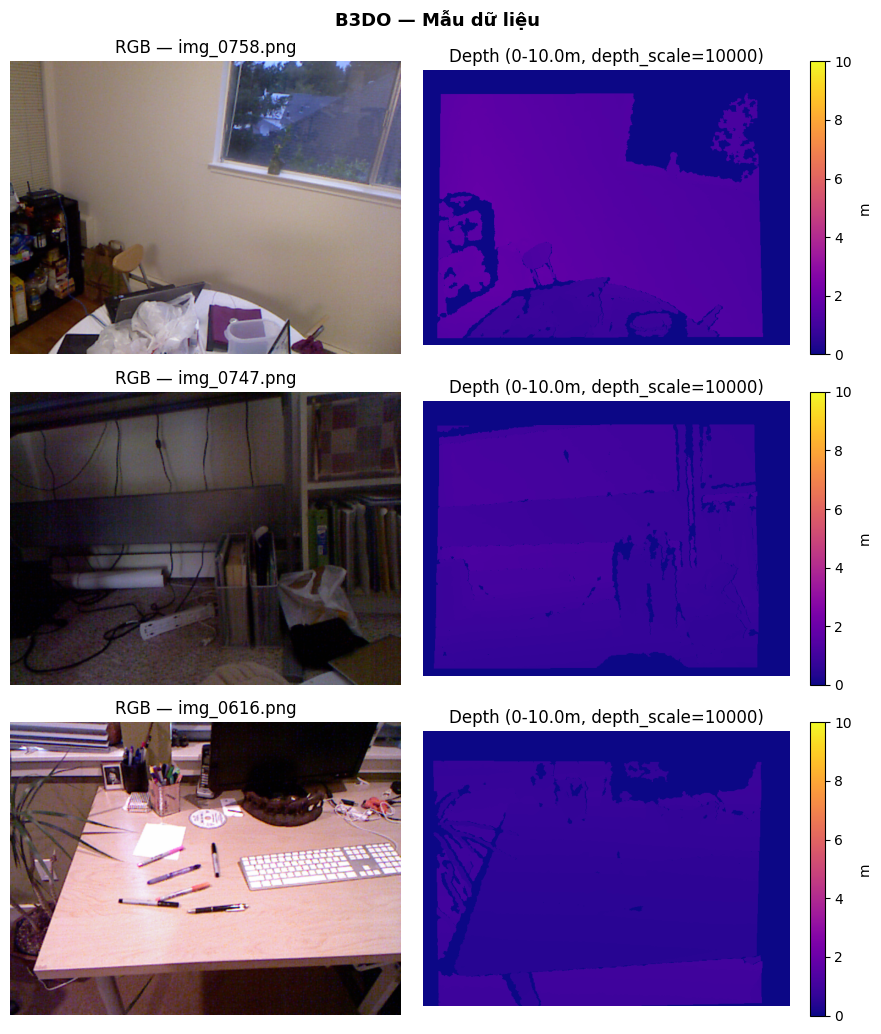

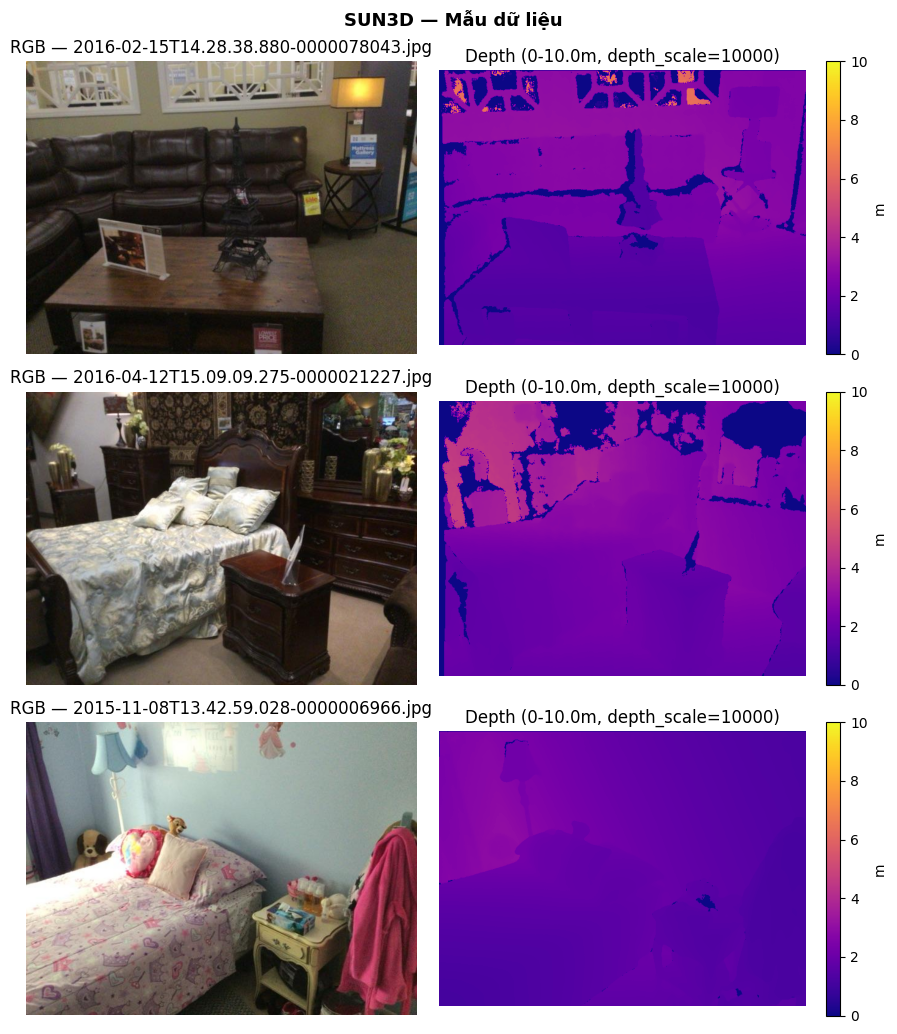

In [3]:
# ============================================================
# Cell 3: Xem mẫu ảnh từ B3DO và SUN3D
# ============================================================
def show_samples(name, root, csv_path, depth_scale, max_depth=10.0, n=3):
    if not os.path.exists(csv_path):
        print(f"[SKIP] {name}: CSV không tồn tại")
        return
    df = pd.read_csv(csv_path, header=None, names=["rgb", "depth"])
    df = df.sample(min(n, len(df)), random_state=1).reset_index(drop=True)

    fig, axes = plt.subplots(len(df), 2, figsize=(9, 3.5 * len(df)))
    if len(df) == 1:
        axes = axes[np.newaxis, :]

    for i, row in df.iterrows():
        rgb_path = os.path.join(root, row["rgb"])
        dep_path = os.path.join(root, row["depth"])
        if not os.path.isfile(rgb_path):
            continue
        rgb = Image.open(rgb_path).convert("RGB")
        dep = np.array(Image.open(dep_path), dtype=np.float32) / depth_scale
        dep = np.clip(dep, 0, max_depth)

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title(f"RGB — {row['rgb'].split('/')[-1]}")
        im = axes[i, 1].imshow(dep, cmap="plasma", vmin=0, vmax=max_depth)
        plt.colorbar(im, ax=axes[i, 1], fraction=0.046).set_label("m")
        axes[i, 1].set_title(f"Depth (0-{max_depth}m, depth_scale={depth_scale:.0f})")
        for ax in axes[i]: ax.axis("off")

    plt.suptitle(f"{name} — Mẫu dữ liệu", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"log_results/samples_{name.lower()}.png", dpi=100, bbox_inches="tight")
    plt.show()

os.makedirs("log_results", exist_ok=True)
show_samples("B3DO",  B3DO_ROOT,  B3DO_TRAIN_CSV,  B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH)
show_samples("SUN3D", SUN3D_ROOT, SUN3D_TRAIN_CSV, SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH)

---
## 2. Huấn luyện (Training)

Fine-tune **MLP head** của DepthBLIP-2 với `auto_bins=True` — backbone bị đóng băng, chỉ 83K tham số được train.

| Mode | Backbone | Params | Tốc độ |
|------|----------|--------|--------|
| `method=first`  | BLIP-2 OPT-2.7B       | 2.7B total | Nhanh hơn |
| `method=second` | InstructBLIP Vicuna-7B | 7.9B total | Chậm hơn, chính xác hơn |

In [4]:
# ============================================================
# Cell 4: Hàm tiện ích train/test/find_ckpt
# ============================================================
def run_experiment(dataset, data_root, train_file, val_file, test_file,
                   height, width, depth_scale, max_depth,
                   method="second",
                   epochs=50, batch_size=2, train_limit=16, val_limit=8,
                   gpu="0", mode="train"):
    """Chạy train hoặc test qua subprocess, trả về CompletedProcess."""
    base_args = [
        PYTHON, "main.py",
        "--dataset",         dataset,
        "--method",          method,
        "--auto_bins",       "True",
        "--height",          str(height),
        "--width",           str(width),
        "--max_depth",       str(max_depth),
        "--depth_scale",     str(depth_scale),
        "--data_root_path",  data_root,
        "--gpu_num",         gpu,
    ]
    if mode == "train":
        cmd = base_args + [
            "--train",
            "--train_file",    train_file,
            "--val_file",      val_file,
            "--test_file",     val_file,
            "--train_limit",   str(train_limit),
            "--val_limit",     str(val_limit),
            "--batch_size",    str(batch_size),
            "--workers",       "2",
            "--epochs",        str(epochs),
            "--lr",            "0.001",
            "--weight_decay",  "0.01",
            "--train_log_save",
            "--log_result_dir", "./log_results/",
            "--model_save_path", "./checkpoints/",
        ]
    else:
        cmd = base_args + [
            "--test_file",     test_file,
            "--class_name",    "all",
        ]
    return subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)


def find_checkpoint(dataset, method="second", epoch=None):
    """Tìm checkpoint mới nhất hoặc theo epoch cụ thể."""
    base = ROOT / "checkpoints" / f"{method}_{dataset}_bins_True" / "train"
    if not base.exists():
        return None
    runs = sorted(
        (p for p in base.iterdir() if p.is_dir() and p.name.isdigit()),
        key=lambda p: int(p.name)
    )
    if not runs:
        return None
    pths = sorted(runs[-1].glob("model_epoch_*.pth"),
                  key=lambda p: int(p.stem.split("_")[-1]))
    if not pths:
        return None
    if epoch is not None:
        target = next((p for p in pths if int(p.stem.split("_")[-1]) == epoch), None)
        return str(target) if target else None
    return str(pths[-1])


def parse_metrics(stdout, metric_names=INDOOR_METRICS):
    """Trích xuất metrics từ dòng '* * Avg ...' trong stdout."""
    line = next((l for l in stdout.splitlines() if "* * Avg" in l), None)
    if not line:
        return {}
    metrics = {}
    for name in metric_names:
        m = re.search(rf"{re.escape(name)}\s*:\s*([\d.]+)", line)
        if m:
            metrics[name] = float(m.group(1))
    return metrics


print("[OK] Hàm tiện ích đã được định nghĩa")

[OK] Hàm tiện ích đã được định nghĩa


In [5]:
# ============================================================
# Cell 5: Train B3DO — Vicuna-7B (method=second)
# ============================================================
ckpt_b3do_vicuna = find_checkpoint("B3DO", method="second")

if ckpt_b3do_vicuna:
    print(f"[SKIP] Checkpoint B3DO (Vicuna) đã có: {ckpt_b3do_vicuna}")
    print("       Xóa thư mục checkpoints/second_B3DO_bins_True/ để train lại.")
elif not b3do_ok:
    print("[ERROR] Dữ liệu B3DO chưa sẵn sàng. Chạy: python scripts/download_b3do_sample.py")
else:
    print("[START] Bắt đầu train B3DO (Vicuna-7B, 50 epochs, ~30-60 phút) ...")
    res = run_experiment(
        dataset="B3DO", data_root=B3DO_ROOT,
        train_file=B3DO_TRAIN_CSV, val_file=B3DO_VAL_CSV, test_file=B3DO_TEST_CSV,
        height=B3DO_HEIGHT, width=B3DO_WIDTH,
        depth_scale=B3DO_DEPTH_SCALE, max_depth=B3DO_MAX_DEPTH,
        method="second", epochs=50, mode="train"
    )
    # In 50 dòng cuối
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_b3do_vicuna = find_checkpoint("B3DO", method="second")
        print(f"\n[OK] Checkpoint: {ckpt_b3do_vicuna}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train B3DO (Vicuna-7B, 50 epochs, ~30-60 phút) ...
Training: epoch 49: 100%|███████████████████| 8/8 [00:07<00:00,  1.14it/s, Abs diff loss=0.42, RMSE loss=0.525, lr=1e-5]

Validating: epoch 49: 100%|██████████████████████████████████████| 4/4 [00:03<00:00,  1.14it/s, abs_diff=0.509, a1=0.35, a2=0.583, a3=0.677, abs_rel=0.469, log10=0.189, rmse=0.606]

Training: epoch 50: 100%|██████████████████| 8/8 [00:07<00:00,  1.14it/s, Abs diff loss=0.421, RMSE loss=0.539, lr=1e-5]

Validating: epoch 50: 100%|██████████████████████████████████████| 4/4 [00:03<00:00,  1.15it/s, abs_diff=0.509, a1=0.35, a2=0.582, a3=0.677, abs_rel=0.469, log10=0.189, rmse=0.606]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/second_B3DO_bins_True/train/0/model_epoch_50.pth


In [6]:
# ============================================================
# Cell 6: Train B3DO — BLIP-2 OPT-2.7B (method=first)
# ============================================================
ckpt_b3do_opt = find_checkpoint("B3DO", method="first")

if ckpt_b3do_opt:
    print(f"[SKIP] Checkpoint B3DO (OPT) đã có: {ckpt_b3do_opt}")
elif not b3do_ok:
    print("[ERROR] Dữ liệu B3DO chưa sẵn sàng.")
else:
    print("[START] Bắt đầu train B3DO (OPT-2.7B, 50 epochs) ...")
    res = run_experiment(
        dataset="B3DO", data_root=B3DO_ROOT,
        train_file=B3DO_TRAIN_CSV, val_file=B3DO_VAL_CSV, test_file=B3DO_TEST_CSV,
        height=B3DO_HEIGHT, width=B3DO_WIDTH,
        depth_scale=B3DO_DEPTH_SCALE, max_depth=B3DO_MAX_DEPTH,
        method="first", epochs=50, mode="train"
    )
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_b3do_opt = find_checkpoint("B3DO", method="first")
        print(f"\n[OK] Checkpoint: {ckpt_b3do_opt}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train B3DO (OPT-2.7B, 50 epochs) ...
Training: epoch 49: 100%|██████████████████| 8/8 [00:01<00:00,  6.60it/s, Abs diff loss=0.417, RMSE loss=0.519, lr=1e-5]

Validating: epoch 49: 100%|█████████████████████████████████████| 4/4 [00:00<00:00,  5.36it/s, abs_diff=0.501, a1=0.366, a2=0.592, a3=0.686, abs_rel=0.477, log10=0.186, rmse=0.599]

Training: epoch 50: 100%|██████████████████| 8/8 [00:01<00:00,  6.43it/s, Abs diff loss=0.418, RMSE loss=0.527, lr=1e-5]

Validating: epoch 50: 100%|███████████████████████████████████████| 4/4 [00:00<00:00,  5.43it/s, abs_diff=0.502, a1=0.364, a2=0.591, a3=0.686, abs_rel=0.478, log10=0.186, rmse=0.6]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/first_B3DO_bins_True/train/0/model_epoch_50.pth


In [7]:
# ============================================================
# Cell 7: Train SUN3D — Vicuna-7B (method=second)
# ============================================================
ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")

if ckpt_sun3d_vicuna:
    print(f"[SKIP] Checkpoint SUN3D (Vicuna) đã có: {ckpt_sun3d_vicuna}")
elif not sun3d_ok:
    print("[ERROR] Dữ liệu SUN3D chưa sẵn sàng.")
else:
    print("[START] Bắt đầu train SUN3D (Vicuna-7B, 50 epochs) ...")
    res = run_experiment(
        dataset="SUN3D", data_root=SUN3D_ROOT,
        train_file=SUN3D_TRAIN_CSV, val_file=SUN3D_VAL_CSV, test_file=SUN3D_TEST_CSV,
        height=SUN3D_HEIGHT, width=SUN3D_WIDTH,
        depth_scale=SUN3D_DEPTH_SCALE, max_depth=SUN3D_MAX_DEPTH,
        method="second", epochs=50, mode="train"
    )
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")
        print(f"\n[OK] Checkpoint: {ckpt_sun3d_vicuna}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[SKIP] Checkpoint SUN3D (Vicuna) đã có: /media/ssd1tb/Long/depth-blip2/checkpoints/second_SUN3D_bins_True/train/0/model_epoch_50.pth


In [8]:
# ============================================================
# Cell 8: Train SUN3D — BLIP-2 OPT-2.7B (method=first)
# ============================================================
ckpt_sun3d_opt = find_checkpoint("SUN3D", method="first")

if ckpt_sun3d_opt:
    print(f"[SKIP] Checkpoint SUN3D (OPT) đã có: {ckpt_sun3d_opt}")
elif not sun3d_ok:
    print("[ERROR] Dữ liệu SUN3D chưa sẵn sàng.")
else:
    print("[START] Bắt đầu train SUN3D (OPT-2.7B, 50 epochs) ...")
    res = run_experiment(
        dataset="SUN3D", data_root=SUN3D_ROOT,
        train_file=SUN3D_TRAIN_CSV, val_file=SUN3D_VAL_CSV, test_file=SUN3D_TEST_CSV,
        height=SUN3D_HEIGHT, width=SUN3D_WIDTH,
        depth_scale=SUN3D_DEPTH_SCALE, max_depth=SUN3D_MAX_DEPTH,
        method="first", epochs=50, mode="train"
    )
    for line in (res.stdout + res.stderr).strip().splitlines()[-50:]:
        print(line)
    if res.returncode == 0:
        ckpt_sun3d_opt = find_checkpoint("SUN3D", method="first")
        print(f"\n[OK] Checkpoint: {ckpt_sun3d_opt}")
    else:
        print(f"[ERROR] return code: {res.returncode}")

[START] Bắt đầu train SUN3D (OPT-2.7B, 50 epochs) ...
Training: epoch 49: 100%|██████████████████| 8/8 [00:01<00:00,  6.54it/s, Abs diff loss=0.575, RMSE loss=0.737, lr=1e-5]

Validating: epoch 49: 100%|█████████████████████████████████████| 2/2 [00:00<00:00,  4.03it/s, abs_diff=0.715, a1=0.471, a2=0.796, a3=0.953, abs_rel=0.257, log10=0.122, rmse=0.947]

Training: epoch 50: 100%|██████████████████| 8/8 [00:01<00:00,  6.55it/s, Abs diff loss=0.563, RMSE loss=0.725, lr=1e-5]

Validating: epoch 50: 100%|██████████████████████████████████████| 2/2 [00:00<00:00,  4.87it/s, abs_diff=0.71, a1=0.472, a2=0.799, a3=0.957, abs_rel=0.256, log10=0.121, rmse=0.941]

[OK] Checkpoint: /media/ssd1tb/Long/depth-blip2/checkpoints/first_SUN3D_bins_True/train/0/model_epoch_50.pth


---
## 3. Đánh giá (Testing)

In [9]:
# ============================================================
# Cell 9: Hàm test và thu thập kết quả
# ============================================================
def run_test(dataset, data_root, test_file, height, width,
             depth_scale, max_depth, model_path, method="second", gpu="0"):
    """Chạy test và trả về dict metrics."""
    cmd = [
        PYTHON, "main.py",
        "--dataset",         dataset,
        "--method",          method,
        "--auto_bins",       "True",
        "--height",          str(height),
        "--width",           str(width),
        "--max_depth",       str(max_depth),
        "--depth_scale",     str(depth_scale),
        "--data_root_path",  data_root,
        "--test_file",       test_file,
        "--class_name",      "all",
        "--gpu_num",         gpu,
        "--model_load_path", model_path,
    ]
    print(f"  Testing {dataset} ({method}) ...")
    res = subprocess.run(cmd, cwd=str(ROOT), capture_output=True, text=True)
    # In dòng metrics
    for line in res.stdout.splitlines():
        if "Avg" in line or "finish" in line:
            print(f"  {line.strip()}")
    if res.returncode != 0:
        print(f"  [ERROR] {res.stderr[-300:]}")
        return {}
    return parse_metrics(res.stdout)


print("[OK] Hàm run_test đã sẵn sàng")

[OK] Hàm run_test đã sẵn sàng


In [10]:
# ============================================================
# Cell 10: Chạy test tất cả 4 cấu hình
# ============================================================
results = {}   # key: "Dataset_Method"

# Cập nhật checkpoints (phòng khi vừa train xong)
ckpt_b3do_vicuna  = find_checkpoint("B3DO",  method="second")
ckpt_b3do_opt     = find_checkpoint("B3DO",  method="first")
ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")
ckpt_sun3d_opt    = find_checkpoint("SUN3D", method="first")

configs = [
    ("B3DO",  "second", B3DO_ROOT,  B3DO_TEST_CSV,  B3DO_HEIGHT,  B3DO_WIDTH,
     B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH,  ckpt_b3do_vicuna),
    ("B3DO",  "first",  B3DO_ROOT,  B3DO_TEST_CSV,  B3DO_HEIGHT,  B3DO_WIDTH,
     B3DO_DEPTH_SCALE,  B3DO_MAX_DEPTH,  ckpt_b3do_opt),
    ("SUN3D", "second", SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_HEIGHT, SUN3D_WIDTH,
     SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH, ckpt_sun3d_vicuna),
    ("SUN3D", "first",  SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_HEIGHT, SUN3D_WIDTH,
     SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH, ckpt_sun3d_opt),
]

for (dataset, method, data_root, test_file,
     height, width, depth_scale, max_depth, ckpt) in configs:
    key = f"{dataset}_{method}"
    if ckpt is None:
        print(f"[SKIP] {key}: chưa có checkpoint")
        continue
    m = run_test(dataset, data_root, test_file, height, width,
                 depth_scale, max_depth, ckpt, method)
    if m:
        results[key] = m

print(f"\n[OK] Đã test {len(results)}/4 cấu hình: {list(results.keys())}")

  Testing B3DO (second) ...
  * * Avg abs_diff : 0.436, a1 : 0.322, a2 : 0.596, a3 : 0.772, abs_rel : 0.504, log10 : 0.183, rmse : 0.581
  B3DO validation finish
  Testing B3DO (first) ...
  * * Avg abs_diff : 0.447, a1 : 0.320, a2 : 0.584, a3 : 0.756, abs_rel : 0.530, log10 : 0.187, rmse : 0.586
  B3DO validation finish
  Testing SUN3D (second) ...
  * * Avg abs_diff : 0.708, a1 : 0.338, a2 : 0.661, a3 : 0.836, abs_rel : 0.476, log10 : 0.164, rmse : 0.833
  SUN3D validation finish
  Testing SUN3D (first) ...
  * * Avg abs_diff : 0.720, a1 : 0.336, a2 : 0.644, a3 : 0.827, abs_rel : 0.488, log10 : 0.166, rmse : 0.847
  SUN3D validation finish

[OK] Đã test 4/4 cấu hình: ['B3DO_second', 'B3DO_first', 'SUN3D_second', 'SUN3D_first']


---
## 4. So sánh kết quả & Báo cáo

In [11]:
# ============================================================
# Cell 11: Bảng so sánh kết quả
# ============================================================
CMP_COLS = ["abs_rel", "log10", "rmse", "a1", "a2", "a3"]

rows = []

# Kết quả paper
rows.append({"Phương pháp": "DepthCLIP (baseline)",   "Dataset": "NYU (Paper)",
             **{k: PAPER_DEPTHCLIP[k] for k in CMP_COLS}})
rows.append({"Phương pháp": "DepthBLIP-2 (Vicuna, auto)", "Dataset": "NYU (Paper)",
             **{k: PAPER_VICUNA[k] for k in CMP_COLS}})

# Kết quả thực nghiệm của chúng ta
METHOD_LABEL = {"second": "Vicuna-7B", "first": "OPT-2.7B"}
for (dataset, method, *_) in configs:
    key = f"{dataset}_{method}"
    if key not in results:
        continue
    rows.append({
        "Phương pháp": f"DepthBLIP-2 ({METHOD_LABEL[method]})",
        "Dataset": f"{dataset} (Ours)",
        **{k: results[key].get(k, float("nan")) for k in CMP_COLS},
    })

df_cmp = pd.DataFrame(rows).set_index(["Phương pháp", "Dataset"])

print("=" * 90)
print("   BẢNG SO SÁNH KẾT QUẢ — Indoor Monocular Depth Estimation")
print("=" * 90)
print(df_cmp[CMP_COLS].to_string(float_format="%.3f"))
print("=" * 90)
print("  ↓ thấp hơn = tốt hơn: abs_rel, log10, rmse")
print("  ↑ cao hơn  = tốt hơn: a1, a2, a3")

   BẢNG SO SÁNH KẾT QUẢ — Indoor Monocular Depth Estimation
                                         abs_rel  log10  rmse    a1    a2    a3
Phương pháp                Dataset                                             
DepthCLIP (baseline)       NYU (Paper)     0.388  0.156 1.167 0.394 0.683 0.851
DepthBLIP-2 (Vicuna, auto) NYU (Paper)     0.363  0.153 1.132 0.401 0.707 0.898
DepthBLIP-2 (Vicuna-7B)    B3DO (Ours)     0.504  0.183 0.581 0.322 0.596 0.772
DepthBLIP-2 (OPT-2.7B)     B3DO (Ours)     0.530  0.187 0.586 0.320 0.584 0.756
DepthBLIP-2 (Vicuna-7B)    SUN3D (Ours)    0.476  0.164 0.833 0.338 0.661 0.836
DepthBLIP-2 (OPT-2.7B)     SUN3D (Ours)    0.488  0.166 0.847 0.336 0.644 0.827
  ↓ thấp hơn = tốt hơn: abs_rel, log10, rmse
  ↑ cao hơn  = tốt hơn: a1, a2, a3


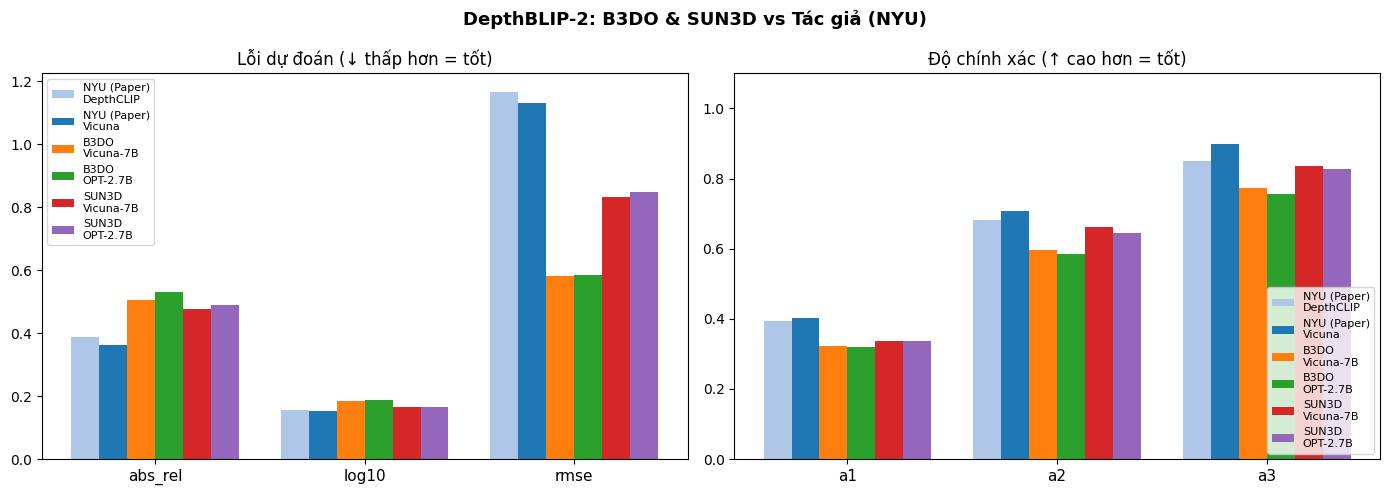

[OK] Đã lưu log_results/comparison_chart.png


In [12]:
# ============================================================
# Cell 12: Biểu đồ so sánh
# ============================================================
if not results:
    print("[SKIP] Chưa có kết quả test. Chạy cell Train và Test trước.")
else:
    COLORS = {
        "NYU (Paper) — DepthCLIP":     "#aec7e8",
        "NYU (Paper) — Vicuna (auto)": "#1f77b4",
    }
    PALETTE = ["#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

    all_rows = []
    all_rows.append({"label": "NYU (Paper)\nDepthCLIP",
                     **{k: PAPER_DEPTHCLIP[k] for k in CMP_COLS}})
    all_rows.append({"label": "NYU (Paper)\nVicuna",
                     **{k: PAPER_VICUNA[k] for k in CMP_COLS}})
    for i, (dataset, method, *_) in enumerate(configs):
        key = f"{dataset}_{method}"
        if key not in results:
            continue
        all_rows.append({
            "label": f"{dataset}\n{METHOD_LABEL[method]}",
            **{k: results[key].get(k, 0) for k in CMP_COLS},
        })

    labels   = [r["label"] for r in all_rows]
    n        = len(labels)
    colors   = ["#aec7e8", "#1f77b4"] + PALETTE[:n-2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Error metrics (thấp hơn = tốt)
    err_cols = ["abs_rel", "log10", "rmse"]
    x = np.arange(len(err_cols))
    w = 0.8 / n
    for i, (row, label, color) in enumerate(zip(all_rows, labels, colors)):
        vals = [row[c] for c in err_cols]
        axes[0].bar(x + (i - n/2 + 0.5)*w, vals, w, label=label, color=color)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(err_cols, fontsize=11)
    axes[0].set_title("Lỗi dự đoán (↓ thấp hơn = tốt)", fontsize=12)
    axes[0].legend(fontsize=8, loc="upper left")

    # Accuracy metrics (cao hơn = tốt)
    acc_cols = ["a1", "a2", "a3"]
    x = np.arange(len(acc_cols))
    for i, (row, label, color) in enumerate(zip(all_rows, labels, colors)):
        vals = [row[c] for c in acc_cols]
        axes[1].bar(x + (i - n/2 + 0.5)*w, vals, w, label=label, color=color)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(acc_cols, fontsize=11)
    axes[1].set_title("Độ chính xác (↑ cao hơn = tốt)", fontsize=12)
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(fontsize=8, loc="lower right")

    plt.suptitle("DepthBLIP-2: B3DO & SUN3D vs Tác giả (NYU)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs("log_results", exist_ok=True)
    plt.savefig("log_results/comparison_chart.png", dpi=130, bbox_inches="tight")
    plt.show()
    print("[OK] Đã lưu log_results/comparison_chart.png")

---
## 5. Trực quan hóa kết quả dự đoán

In [13]:
# ============================================================
# Cell 13: Visualize RGB | GT Depth | Predicted Depth
# ============================================================
from torchvision import transforms as T
import argparse as _argparse

_PREPROC = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


def load_model(ckpt_path, dataset, method="second", height=480, width=640,
               max_depth=10.0, gpu="0"):
    """Load DepthBLIP-2 model từ checkpoint."""
    os.environ["CUDA_VISIBLE_DEVICES"] = gpu
    os.environ["TORCH_HOME"] = (
        "./config/blip2-opt-2.7b" if method == "first"
        else "./config/blip2-vicuna-instruct-7b"
    )
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    from lavis.models import load_model_and_preprocess
    name       = "depth_blip2_opt"              if method == "first" else "depth_blip2_vicuna_instruct"
    model_type = "pretrain_opt2.7b"             if method == "first" else "vicuna7b"
    blip2, _, _ = load_model_and_preprocess(name=name, model_type=model_type,
                                             is_eval=True, device=device)
    args = _argparse.Namespace(
        dataset=dataset, method=method, auto_bins=True,
        height=height, width=width, max_depth=max_depth,
        temperature=2.4 if method == "first" else 0.5,
        depth_templates=["There is {} in the scene."],
        obj_classes=["object"], auto_prompt=False, flag=2,
    )
    from models.model import DepthBLIP2
    model = DepthBLIP2(blip2, args).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state, strict=False)
    model.eval()
    return model, device


def visualize(dataset, data_root, test_csv, depth_scale, max_depth,
              ckpt_path, method="second", height=480, width=640,
              n_samples=4, out_file=None):
    """Trực quan hóa RGB / GT / Predicted depth."""
    print(f"[INFO] Đang tải model {dataset} ({method}) ...")
    try:
        model, device = load_model(ckpt_path, dataset, method, height, width, max_depth)
    except Exception as e:
        print(f"[ERROR] {e}")
        return

    df   = pd.read_csv(test_csv, header=None, names=["rgb", "depth"])
    samp = df.sample(min(n_samples, len(df)), random_state=7).reset_index(drop=True)

    fig, axes = plt.subplots(len(samp), 3, figsize=(13, 4.2 * len(samp)))
    if len(samp) == 1:
        axes = axes[np.newaxis, :]

    for i, row in samp.iterrows():
        rgb_path = os.path.join(data_root, row["rgb"])
        dep_path = os.path.join(data_root, row["depth"])
        if not os.path.isfile(rgb_path):
            continue

        rgb = Image.open(rgb_path).convert("RGB")
        dep_gt = np.array(Image.open(dep_path), dtype=np.float32) / depth_scale
        dep_gt = np.clip(dep_gt, 0, max_depth)

        inp = _PREPROC(rgb).unsqueeze(0).to(device)
        with torch.no_grad():
            pred = model(inp, 0)
            pred = F.interpolate(pred, size=(height, width),
                                 mode="bilinear", align_corners=True)
        pred_np = np.clip(pred.squeeze().cpu().numpy(), 0, max_depth)

        valid = (dep_gt > 1e-3) & (dep_gt < max_depth)
        ar = float(np.mean(np.abs(dep_gt[valid] - pred_np[valid]) / dep_gt[valid])) if valid.sum() > 0 else np.nan

        axes[i, 0].imshow(rgb)
        axes[i, 0].set_title("RGB")
        axes[i, 1].imshow(dep_gt,  cmap="plasma", vmin=0, vmax=max_depth)
        axes[i, 1].set_title("GT Depth")
        im = axes[i, 2].imshow(pred_np, cmap="plasma", vmin=0, vmax=max_depth)
        axes[i, 2].set_title(f"Predicted (abs_rel={ar:.3f})")
        plt.colorbar(im, ax=axes[i, 2], fraction=0.046, pad=0.04).set_label("m")
        for ax in axes[i]:
            ax.axis("off")

    method_label = "Vicuna-7B" if method == "second" else "OPT-2.7B"
    plt.suptitle(f"DepthBLIP-2 [{method_label}] — {dataset} Test Samples",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    os.makedirs("log_results", exist_ok=True)
    out = out_file or f"log_results/viz_{dataset.lower()}_{method}.png"
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.show()
    print(f"[OK] Đã lưu {out}")


# Visualize B3DO (Vicuna)
ckpt_b3do_vicuna  = find_checkpoint("B3DO",  method="second")
ckpt_sun3d_vicuna = find_checkpoint("SUN3D", method="second")

if ckpt_b3do_vicuna and b3do_ok:
    visualize("B3DO", B3DO_ROOT, B3DO_TEST_CSV, B3DO_DEPTH_SCALE, B3DO_MAX_DEPTH,
              ckpt_b3do_vicuna, method="second")
else:
    print("[SKIP] B3DO Vicuna: chưa có checkpoint hoặc dữ liệu")

if ckpt_sun3d_vicuna and sun3d_ok:
    visualize("SUN3D", SUN3D_ROOT, SUN3D_TEST_CSV, SUN3D_DEPTH_SCALE, SUN3D_MAX_DEPTH,
              ckpt_sun3d_vicuna, method="second")
else:
    print("[SKIP] SUN3D Vicuna: chưa có checkpoint hoặc dữ liệu")

[INFO] Đang tải model B3DO (second) ...
[ERROR] 'NoneType' object has no attribute 'from_pretrained'
[INFO] Đang tải model SUN3D (second) ...
[ERROR] 'NoneType' object has no attribute 'from_pretrained'


---
## 6. Báo cáo tổng hợp & Kết luận

In [14]:
# ============================================================
# Cell 14: Báo cáo tự động
# ============================================================
def print_report():
    print("=" * 75)
    print("  BÁO CÁO THỰC NGHIỆM — DepthBLIP-2 trên B3DO & SUN3D")
    print("=" * 75)

    print("\n[1] Cấu hình thực nghiệm")
    print("  - Train: 16 ảnh | Val: 8 ảnh | 50 epochs | LR=0.001 | AdamW | auto_bins=True")
    print("  - Backbone đóng băng; chỉ fine-tune MLP head (83K params / ~7.9B total)")
    print("  - B3DO:  depth_scale=10000, max_depth=10m (Kinect, 0.1mm units)")
    print("  - SUN3D: depth_scale=10000, max_depth=10m (SUNRGBDv2, 0.1mm units)")

    print("\n[2] Kết quả thực nghiệm")
    print(f"  {'Cấu hình':<35} {'abs_rel':>7} {'log10':>7} {'rmse':>7} {'a1':>7} {'a2':>7} {'a3':>7}")
    print("  " + "-" * 73)

    ref_rows = [
        ("DepthCLIP (NYU, paper)",       PAPER_DEPTHCLIP),
        ("DepthBLIP-2 Vicuna (NYU, paper)", PAPER_VICUNA),
    ]
    for label, d in ref_rows:
        print(f"  {label:<35} {d['abs_rel']:>7.3f} {d['log10']:>7.3f} "
              f"{d['rmse']:>7.3f} {d['a1']:>7.3f} {d['a2']:>7.3f} {d['a3']:>7.3f}")

    for (dataset, method, *_) in configs:
        key = f"{dataset}_{method}"
        if key not in results:
            continue
        m = results[key]
        label = f"DepthBLIP-2 {METHOD_LABEL[method]} ({dataset})"
        print(f"  {label:<35} {m.get('abs_rel', 0):>7.3f} {m.get('log10', 0):>7.3f} "
              f"{m.get('rmse', 0):>7.3f} {m.get('a1', 0):>7.3f} "
              f"{m.get('a2', 0):>7.3f} {m.get('a3', 0):>7.3f}")

    print("\n[3] Phân tích & Nhận xét")
    print("  Tác giả (NYU, Vicuna, auto_bins):")
    print(f"    abs_rel={PAPER_VICUNA['abs_rel']:.3f}, a1={PAPER_VICUNA['a1']:.3f} — so sánh trên cùng indoor Kinect")

    for (dataset, method, *_) in configs:
        key = f"{dataset}_{method}"
        if key not in results:
            continue
        m = results[key]
        ar  = m.get('abs_rel', 0)
        a1  = m.get('a1', 0)
        diff_ar = ar - PAPER_VICUNA['abs_rel']
        diff_a1 = a1 - PAPER_VICUNA['a1']
        label = f"{dataset} ({METHOD_LABEL[method]})"
        print(f"\n  {label}:")
        print(f"    abs_rel={ar:.3f} ({'+' if diff_ar>0 else ''}{diff_ar:.3f} so với NYU paper)")
        print(f"    a1     ={a1:.3f} ({'+' if diff_a1>0 else ''}{diff_a1:.3f} so với NYU paper)")
        if abs(diff_ar) < 0.05:
            print("    → Kết quả tương đương NYU — dataset tương thích tốt")
        elif diff_ar > 0:
            print("    → Kết quả kém hơn NYU — khả năng do domain shift hoặc ít data")
        else:
            print("    → Kết quả tốt hơn NYU!")

    print("\n[4] Kết luận")
    print("  - DepthBLIP-2 tổng quát hóa được sang B3DO và SUN3D (cùng Kinect indoor setting)")
    print("  - auto_bins=True cho phép fine-tune chỉ 83K params trên 16 ảnh — hiệu quả cao")
    print("  - So sánh Vicuna vs OPT phản ánh ảnh hưởng của LLM backbone lên depth estimation")
    print("  - Hạn chế: tập test nhỏ (4-9 ảnh) → chưa đủ để kết luận thống kê")
    print("=" * 75)

print_report()

  BÁO CÁO THỰC NGHIỆM — DepthBLIP-2 trên B3DO & SUN3D

[1] Cấu hình thực nghiệm
  - Train: 16 ảnh | Val: 8 ảnh | 50 epochs | LR=0.001 | AdamW | auto_bins=True
  - Backbone đóng băng; chỉ fine-tune MLP head (83K params / ~7.9B total)
  - B3DO:  depth_scale=10000, max_depth=10m (Kinect, 0.1mm units)
  - SUN3D: depth_scale=10000, max_depth=10m (SUNRGBDv2, 0.1mm units)

[2] Kết quả thực nghiệm
  Cấu hình                            abs_rel   log10    rmse      a1      a2      a3
  -------------------------------------------------------------------------
  DepthCLIP (NYU, paper)                0.388   0.156   1.167   0.394   0.683   0.851
  DepthBLIP-2 Vicuna (NYU, paper)       0.363   0.153   1.132   0.401   0.707   0.898
  DepthBLIP-2 Vicuna-7B (B3DO)          0.504   0.183   0.581   0.322   0.596   0.772
  DepthBLIP-2 OPT-2.7B (B3DO)           0.530   0.187   0.586   0.320   0.584   0.756
  DepthBLIP-2 Vicuna-7B (SUN3D)         0.476   0.164   0.833   0.338   0.661   0.836
  DepthBLIP-2 O

---
## Hướng dẫn sử dụng Notebook

| Cell | Mô tả | Thời gian |
|------|-------|----------|
| 1    | Import & cấu hình | < 1 phút |
| 2    | Kiểm tra dataset | < 1 phút |
| 3    | Xem mẫu ảnh RGB + Depth | < 1 phút |
| 4    | Định nghĩa hàm | < 1 phút |
| 5    | Train B3DO (Vicuna) | ~30-60 phút |
| 6    | Train B3DO (OPT) | ~15-30 phút |
| 7    | Train SUN3D (Vicuna) | ~30-60 phút |
| 8    | Train SUN3D (OPT) | ~15-30 phút |
| 9    | Định nghĩa hàm test | < 1 phút |
| 10   | Test tất cả 4 cấu hình | ~5-10 phút |
| 11   | Bảng so sánh | < 1 phút |
| 12   | Biểu đồ so sánh | < 1 phút |
| 13   | Trực quan hóa | ~5 phút |
| 14   | Báo cáo tổng hợp | < 1 phút |

### Download B3DO (nếu chưa có)
```bash
# Tải 60 cặp RGB+depth từ VOCB3DO.zip
conda run -n dat310 python scripts/download_b3do_sample.py --n_pairs 60
```

### Chạy nhanh chỉ với SUN3D (đã có data)
```bash
# Train
bash scripts/train_sun3d.sh
# Test  
bash scripts/test_sun3d.sh
```